In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("Bibliotecas importadas com sucesso")

Bibliotecas importadas com sucesso


## 1. Import Required Libraries

# Random Forest com Velocidade Angular

Este notebook consome `frames_processados_v1.csv`, gerado no notebook 0. Ele cria deltas angulares a partir dos frames já validados, mantendo `video_id` e `participant_id` em cada janela.

A avaliação é Leave-One-Subject-Out: um participante inteiro é reservado para teste em cada fold, e o scaler é ajustado somente nos dados de treino.

## 2. Load and Explore Data

In [2]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "files_processados"
DATASET_VERSION = "v1"
WINDOW_SIZE = 15
STRIDE = 1

FRAMES_DATASET_PATH = PROCESSED_DATA_DIR / f"frames_processados_{DATASET_VERSION}.csv"
MANIFEST_PATH = PROCESSED_DATA_DIR / f"manifesto_dataset_{DATASET_VERSION}.json"
ML_MODELS_DIR = PROJECT_ROOT / "ml_models"
ML_MODELS_DIR.mkdir(exist_ok=True)

assert FRAMES_DATASET_PATH.is_file(), (
    f"Dataset não encontrado: {FRAMES_DATASET_PATH}. "
    "Execute primeiro o notebook 0-preprocessamento_dataset.ipynb."
)
with MANIFEST_PATH.open(encoding="utf-8") as manifest_file:
    manifest = json.load(manifest_file)

ANGLE_COLUMNS = [
    "right_cotovelo", "left_cotovelo", "right_ombro", "left_ombro",
    "right_joelho", "left_joelho", "right_quadril", "left_quadril",
]
angle_columns = ANGLE_COLUMNS
required_columns = {
    "video_id", "participant_id", "exercise_label", "frame", "timestamp_s",
    "is_valid_frame", *ANGLE_COLUMNS,
}
data = pd.read_csv(FRAMES_DATASET_PATH)
missing_columns = required_columns - set(data.columns)
if missing_columns:
    raise ValueError(f"Dataset incompatível; colunas ausentes: {sorted(missing_columns)}")

data = data.loc[data["is_valid_frame"]].copy()
if data[ANGLE_COLUMNS].isna().any().any():
    raise ValueError("Dataset contém ângulos ausentes em frames considerados válidos.")

print(f"Frames carregados: {len(data):,}")
print(f"Participantes: {sorted(data['participant_id'].unique().tolist())}")
print(f"Vídeos: {data['video_id'].nunique()} | Janela: {WINDOW_SIZE} | Stride: {STRIDE}")

Frames carregados: 15,042
Participantes: ['leticia', 'paulo', 'rafael', 'rodrigo']
Vídeos: 16 | Janela: 15 | Stride: 1


In [3]:
summary_by_subject = (
    data.groupby(["participant_id", "exercise_label"], dropna=False)
    .agg(frames=("frame", "size"), videos=("video_id", "nunique"))
    .reset_index()
    .sort_values(["participant_id", "exercise_label"])
)

print("Resumo dos frames processados:")
display(summary_by_subject)

assert data.groupby("video_id")["participant_id"].nunique().eq(1).all()
assert data.groupby("video_id")["exercise_label"].nunique().eq(1).all()

Resumo dos frames processados:


,participant_id,exercise_label,frames,videos
0,leticia,agachamento,784,1
1,leticia,descanso,866,1
2,leticia,flexao,589,1
3,leticia,rosca_biceps,630,1
4,paulo,agachamento,499,1
5,paulo,descanso,607,1
6,paulo,flexao,509,1
7,paulo,rosca_biceps,691,1
8,rafael,agachamento,1587,1
9,rafael,descanso,1740,1


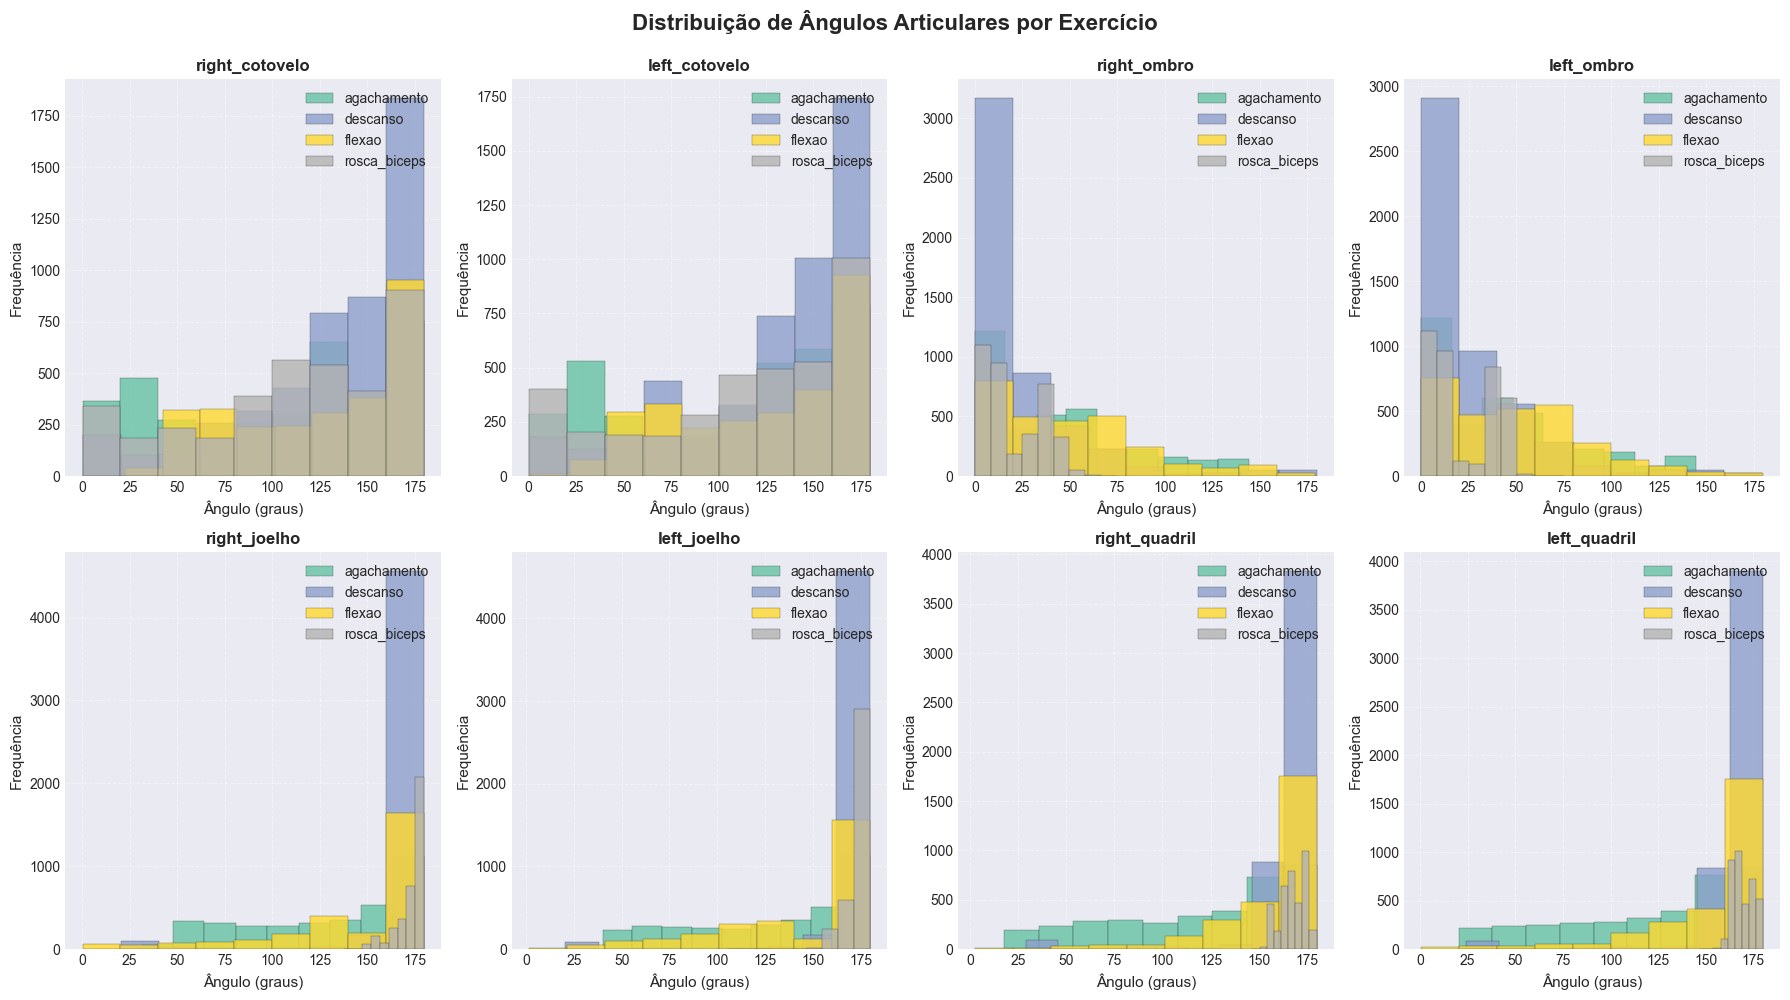

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

exercise_labels = sorted(data["exercise_label"].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(exercise_labels)))
exercise_colors = {exercise: colors[index] for index, exercise in enumerate(exercise_labels)}

for index, angle_column in enumerate(ANGLE_COLUMNS):
    for exercise_label in exercise_labels:
        subset = data.loc[data["exercise_label"].eq(exercise_label), angle_column]
        axes[index].hist(
            subset,
            alpha=0.8,
            label=exercise_label,
            bins=9,
            color=exercise_colors[exercise_label],
            edgecolor="black",
            linewidth=0.2,
        )
    axes[index].set_title(angle_column, fontsize=12, fontweight="bold")
    axes[index].set_xlabel("Ângulo (graus)", fontsize=11)
    axes[index].set_ylabel("Frequência", fontsize=11)
    axes[index].legend(fontsize=10, loc="upper right", framealpha=0.95)
    axes[index].grid(alpha=0.4, linestyle="--")

plt.suptitle("Distribuição de Ângulos Articulares por Exercício", fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

## 3. Velocity Feature Engineering

### Diferença em relação ao notebook 2:
Em vez de usar os **ângulos absolutos** de cada frame na janela, calculamos a **diferença entre frames consecutivos**.

```
Notebook 2 (ângulos brutos):     frame_1_cotovelo, frame_2_cotovelo, ..., frame_15_cotovelo  →  15 × 8 = 120 features
Notebook 3 (velocidade angular): delta_1_cotovelo, delta_2_cotovelo, ..., delta_14_cotovelo  →  14 × 8 = 112 features
  onde delta_i = angle[frame_{i+1}] − angle[frame_i]
```

- **Valor positivo (Δ > 0)**: articulação abrindo (ângulo aumentando)
- **Valor negativo (Δ < 0)**: articulação fechando (ângulo diminuindo)
- **Valor zero (Δ ≈ 0)**: articulação parada

### Hipótese:
A velocidade angular pode ser mais discriminativa que a posição absoluta para exercícios onde o *padrão de movimento* importa mais que a *postura* em si.

In [5]:
def create_velocity_features_window(df, window_size, stride, angle_columns):
    feature_rows = []
    metadata_columns = ["video_id", "participant_id", "exercise_label"]

    for video_id, group in df.groupby("video_id", sort=False):
        group = group.sort_values("frame").reset_index(drop=True)
        for start_index in range(0, len(group) - window_size + 1, stride):
            window = group.iloc[start_index : start_index + window_size]
            first_frame = window.iloc[0]
            row = {
                "window_id": f"{video_id}__start_{int(first_frame['frame'])}__w{window_size}__s{stride}",
                "window_size": window_size,
                "stride": stride,
                "window_start_frame": int(first_frame["frame"]),
                "window_end_frame": int(window.iloc[-1]["frame"]),
                "mean_visibility": float(window["mean_visibility"].mean()),
            }
            row.update(first_frame[metadata_columns].to_dict())

            angles = window[angle_columns].to_numpy(dtype=float)
            deltas = np.diff(angles, axis=0)
            for delta_position, delta_values in enumerate(deltas, start=1):
                for angle_column, delta_value in zip(angle_columns, delta_values):
                    row[f"delta_{delta_position}_{angle_column}"] = delta_value
            feature_rows.append(row)

    velocity_dataset = pd.DataFrame(feature_rows)
    if velocity_dataset.empty or not velocity_dataset["window_id"].is_unique:
        raise ValueError("Não foi possível gerar janelas de velocidade válidas.")
    return velocity_dataset

velocity_dataset = create_velocity_features_window(data, WINDOW_SIZE, STRIDE, ANGLE_COLUMNS)
feature_columns = [
    f"delta_{delta_position}_{angle_column}"
    for delta_position in range(1, WINDOW_SIZE)
    for angle_column in ANGLE_COLUMNS
]
if velocity_dataset[feature_columns].isna().any().any():
    raise ValueError("Há deltas ausentes no dataset de velocidade.")

X = velocity_dataset[feature_columns].astype(float)
y = velocity_dataset["exercise_label"].copy()
meta = velocity_dataset[[
    "window_id", "video_id", "participant_id", "exercise_label",
    "window_start_frame", "window_end_frame", "mean_visibility",
]].copy()

print(f"Janelas de velocidade: {len(X):,} | Features: {X.shape[1]}")
print(f"Esperado: {(WINDOW_SIZE - 1) * len(ANGLE_COLUMNS)} features")

Janelas de velocidade: 14,818 | Features: 112
Esperado: 112 features


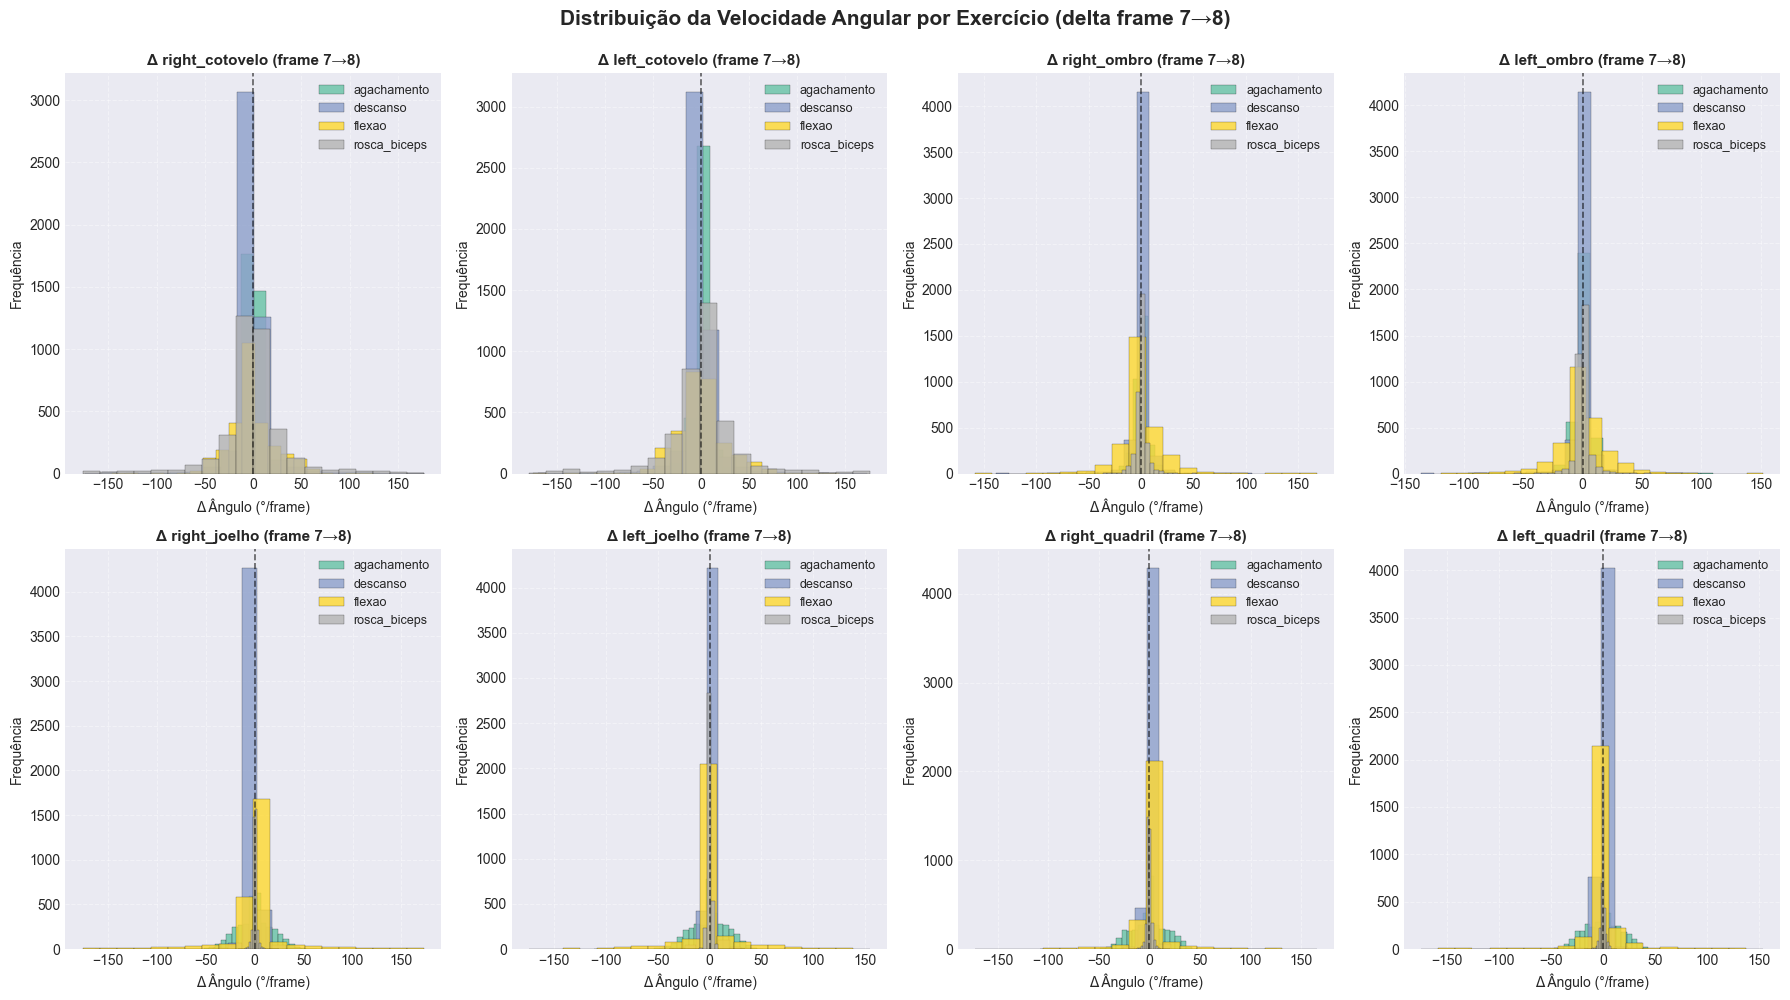

In [6]:
# Visualizar distribuições das features de velocidade
# Esperamos que os deltas durante descanso sejam próximos de zero
# e durante exercícios tenham maior variação
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Usar o delta central (posição 7 de 14) como representativo da janela
delta_cols = [f'delta_7_{col}' for col in angle_columns]

colors = plt.cm.Set2(np.linspace(0, 1, len(y.unique())))
exercise_colors = {ex: colors[i] for i, ex in enumerate(sorted(y.unique()))}

for idx, (delta_col, angle_col) in enumerate(zip(delta_cols, angle_columns)):
    for exercise in sorted(y.unique()):
        subset = X.loc[y == exercise, delta_col]
        axes[idx].hist(subset, alpha=0.8, label=exercise, bins=20,
                       color=exercise_colors[exercise], edgecolor='black', linewidth=0.2)
    axes[idx].axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    axes[idx].set_title(f'Δ {angle_col} (frame 7→8)', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Δ Ângulo (°/frame)', fontsize=10)
    axes[idx].set_ylabel('Frequência', fontsize=10)
    axes[idx].legend(fontsize=9, loc='upper right', framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle='--')

plt.suptitle('Distribuição da Velocidade Angular por Exercício (delta frame 7→8)',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [7]:
y.value_counts()

exercise_label
descanso        4851
rosca_biceps    3695
agachamento     3526
flexao          2746
Name: count, dtype: int64

## 4. Preprocess and Prepare Features

In [8]:
label_map = {"flexao": 0, "agachamento": 1, "descanso": 2, "rosca_biceps": 3}
reverse_label_map = {value: key for key, value in label_map.items()}
y_encoded = y.map(label_map)
if y_encoded.isna().any():
    raise ValueError(f"Classes não mapeadas: {sorted(y[y_encoded.isna()].unique().tolist())}")

TEST_PARTICIPANT = "rodrigo"
participants = sorted(meta["participant_id"].unique().tolist())
if TEST_PARTICIPANT not in participants:
    raise ValueError(f"TEST_PARTICIPANT deve ser um de: {participants}")

train_mask = meta["participant_id"] != TEST_PARTICIPANT
test_mask = ~train_mask
X_train = X.loc[train_mask].reset_index(drop=True)
y_train = y_encoded.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)
y_test = y_encoded.loc[test_mask].reset_index(drop=True)
meta_train = meta.loc[train_mask].reset_index(drop=True)
meta_test = meta.loc[test_mask].reset_index(drop=True)

print(f"Fold detalhado: teste em {TEST_PARTICIPANT}")
print(f"Treino: {len(X_train):,} janelas | participantes: {sorted(meta_train['participant_id'].unique())}")
print(f"Teste: {len(X_test):,} janelas | participante: {TEST_PARTICIPANT}")

Fold detalhado: teste em rodrigo
Treino: 11,286 janelas | participantes: ['leticia', 'paulo', 'rafael']
Teste: 3,532 janelas | participante: rodrigo


In [9]:
def undersample_training_data(X_split, y_split, random_state=42):
    rng = np.random.RandomState(random_state)
    target_count = y_split.value_counts().min()
    selected_indices = np.concatenate([
        rng.choice(y_split.index[y_split.eq(label)], size=target_count, replace=False)
        for label in sorted(y_split.unique())
    ])
    return (
        X_split.loc[selected_indices].reset_index(drop=True),
        y_split.loc[selected_indices].reset_index(drop=True),
    )

X_train, y_train = undersample_training_data(X_train, y_train)
print("Distribuição do treino balanceado:")
display(y_train.map(reverse_label_map).value_counts().rename("windows").to_frame())
print("Distribuição original do teste:")
display(y_test.map(reverse_label_map).value_counts().rename("windows").to_frame())

Distribuição do treino balanceado:


,windows
exercise_label,
flexao,2249
agachamento,2249
descanso,2249
rosca_biceps,2249


Distribuição original do teste:


,windows
exercise_label,
descanso,1680
agachamento,698
rosca_biceps,657
flexao,497


In [10]:
# Pipeline: scaler + modelo em sequência
# O scaler é reajustado a cada fold do CV — sem vazamento de estatísticas.
# Hiperparâmetros idênticos ao notebook 2 para comparação justa.
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=3,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
    ))
])

print("✓ Pipeline criado: StandardScaler → RandomForestClassifier")
print(f"  Steps: {[name for name, _ in pipe.steps]}")
print(f"  Features de entrada: {X_train.shape[1]} (14 deltas × 8 ângulos)")

✓ Pipeline criado: StandardScaler → RandomForestClassifier
  Steps: ['scaler', 'rf']
  Features de entrada: 112 (14 deltas × 8 ângulos)


In [11]:
print(
    "LOSO: cada participant_id é reservado uma vez para teste; "
    "apenas o treino de cada fold é balanceado."
)

LOSO: cada participant_id é reservado uma vez para teste; apenas o treino de cada fold é balanceado.


In [12]:
logo = LeaveOneGroupOut()
loso_records = []

for train_index, test_index in logo.split(X, y_encoded, groups=meta["participant_id"]):
    held_out_participant = meta.iloc[test_index]["participant_id"].iloc[0]
    X_fold_train = X.iloc[train_index].reset_index(drop=True)
    y_fold_train = y_encoded.iloc[train_index].reset_index(drop=True)
    X_fold_test = X.iloc[test_index].reset_index(drop=True)
    y_fold_test = y_encoded.iloc[test_index].reset_index(drop=True)

    X_fold_train, y_fold_train = undersample_training_data(X_fold_train, y_fold_train)
    fold_pipe = clone(pipe)
    fold_pipe.fit(X_fold_train, y_fold_train)
    y_fold_pred = fold_pipe.predict(X_fold_test)

    loso_records.append({
        "test_participant": held_out_participant,
        "train_windows": len(X_fold_train),
        "test_windows": len(X_fold_test),
        "accuracy": accuracy_score(y_fold_test, y_fold_pred),
        "f1_weighted": f1_score(y_fold_test, y_fold_pred, average="weighted"),
        "f1_macro": f1_score(y_fold_test, y_fold_pred, average="macro"),
    })

loso_results = pd.DataFrame(loso_records).sort_values("test_participant").reset_index(drop=True)
display(loso_results)
print(
    f"Média LOSO: accuracy={loso_results['accuracy'].mean():.4f} ± "
    f"{loso_results['accuracy'].std(ddof=0):.4f} | "
    f"F1 macro={loso_results['f1_macro'].mean():.4f} ± "
    f"{loso_results['f1_macro'].std(ddof=0):.4f}"
)

,test_participant,train_windows,test_windows,accuracy,f1_weighted,f1_macro
0,leticia,8684,2813,0.510843,0.498533,0.490789
1,paulo,9004,2250,0.809778,0.803940,0.804045
2,rafael,6268,6223,0.723124,0.734398,0.728485
3,rodrigo,8996,3532,0.489241,0.424632,0.571709


Média LOSO: accuracy=0.6332 ± 0.1369 | F1 macro=0.6488 ± 0.1239


## 5. Train Random Forest Classifier

In [13]:
# Armazenar valores nulos para compatibilidade com célula de resumo
cv_scores_accuracy = np.array([np.nan])
cv_scores_f1       = np.array([np.nan])

# Treinar pipeline em todos os dados de treino
print("🔧 Treinando pipeline com features de velocidade angular...")
pipe.fit(X_train, y_train)
print("✓ Pipeline treinado!")
print(f"  Amostras de treino: {len(X_train)}  |  Features: {X_train.shape[1]}")

🔧 Treinando pipeline com features de velocidade angular...
✓ Pipeline treinado!
  Amostras de treino: 8996  |  Features: 112


## 6. Evaluate Model Performance

In [14]:
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)
y_train_proba = pipe.predict_proba(X_train)
y_test_proba = pipe.predict_proba(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred, average="weighted")
test_f1 = f1_score(y_test, y_test_pred, average="weighted")

try:
    test_auc = roc_auc_score(y_test, y_test_proba, multi_class="ovr")
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class="ovr")
except ValueError:
    train_auc = np.nan
    test_auc = np.nan

cm = confusion_matrix(y_test, y_test_pred, labels=sorted(label_map.values()))
print(f"Resultados do fold com teste em {TEST_PARTICIPANT}:")
print(f"  Accuracy:      {test_accuracy:.4f}  (treino: {train_accuracy:.4f})")
print(f"  F1 ponderado:  {test_f1:.4f}  (treino: {train_f1:.4f})")
if not np.isnan(test_auc):
    print(f"  AUC-ROC (ovr): {test_auc:.4f}  (treino: {train_auc:.4f})")

Resultados do fold com teste em rodrigo:
  Accuracy:      0.4892  (treino: 0.7248)
  F1 ponderado:  0.4246  (treino: 0.7050)
  AUC-ROC (ovr): 0.8493  (treino: 0.9132)


## 7. Visualizando resultado das previsões

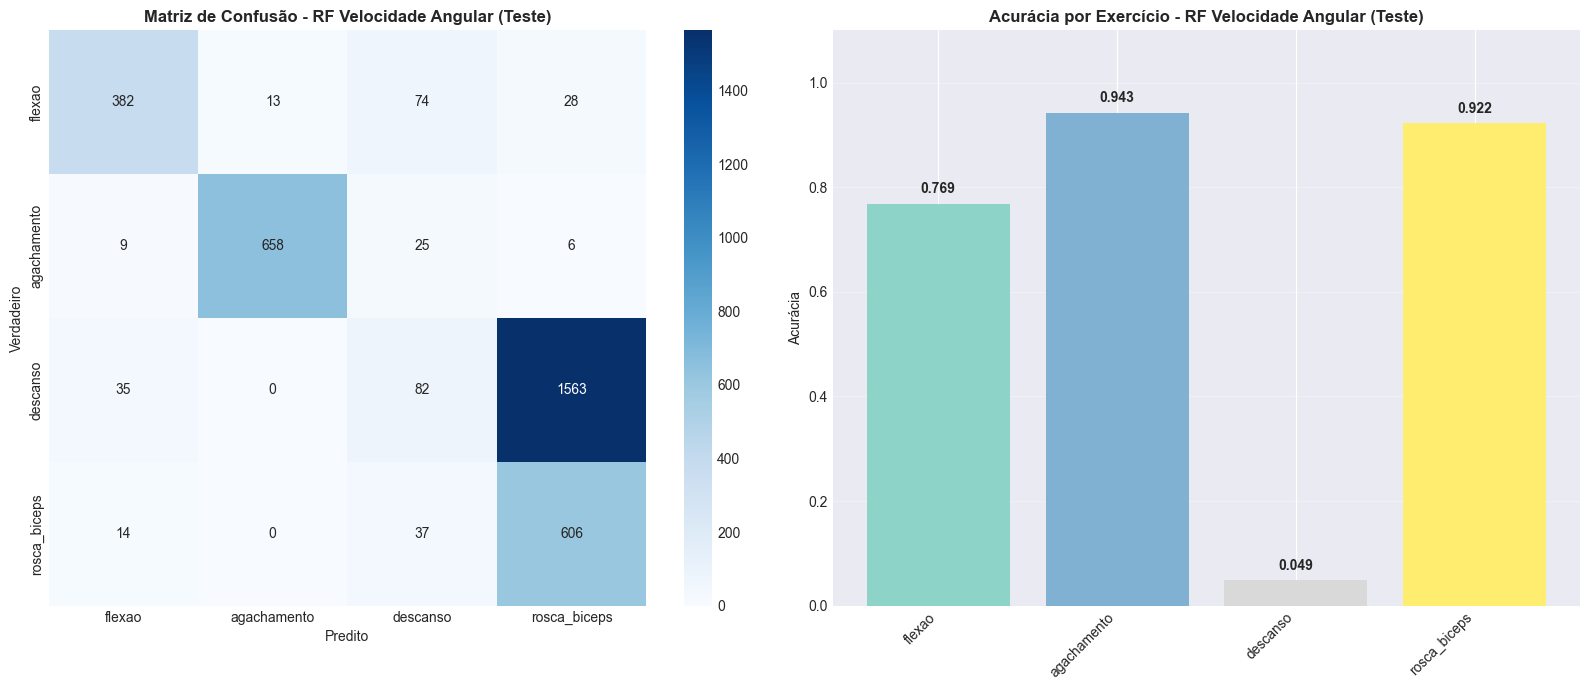

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Matriz de Confusão
exercise_names = [reverse_label_map[i] for i in sorted(label_map.values())]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=exercise_names, yticklabels=exercise_names)
axes[0].set_title('Matriz de Confusão - RF Velocidade Angular (Teste)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Verdadeiro')
axes[0].set_xlabel('Predito')

# 2. Acurácia por Classe
per_class_totals = cm.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    per_class_accuracy = np.where(per_class_totals > 0, cm.diagonal() / per_class_totals, np.nan)
colors_per_class = plt.cm.Set3(np.linspace(0, 1, len(exercise_names)))
axes[1].bar(
    exercise_names,
    [v if not np.isnan(v) else 0 for v in per_class_accuracy],
    color=colors_per_class
)
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia por Exercício - RF Velocidade Angular (Teste)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_accuracy):
    label_txt = f'{v:.3f}' if not np.isnan(v) else 'n/a'
    axes[1].text(i, (v if not np.isnan(v) else 0) + 0.02, label_txt,
                 ha='center', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 7b. Acurácia Apenas em Exercícios Ativos (sem Descanso)

  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)

  Conjunto      Acurácia (active)
  --------------------------------
  Treino                   0.8771
  Teste                    0.8888

  CLASSIFICATION REPORT — TREINO (active)
              precision    recall  f1-score   support

      flexao       0.92      0.85      0.88      2249
 agachamento       0.99      0.88      0.93      2249
rosca_biceps       0.83      0.90      0.86      2249

   micro avg       0.91      0.88      0.89      6747
   macro avg       0.91      0.88      0.89      6747
weighted avg       0.91      0.88      0.89      6747

  CLASSIFICATION REPORT — TESTE (active)
              precision    recall  f1-score   support

      flexao       0.94      0.77      0.85       497
 agachamento       0.98      0.94      0.96       698
rosca_biceps       0.95      0.92      0.93       657

   micro avg       0.96      0.89      0.92      1852
   macro avg       0.96      0.88      0.91      1852
weighted 

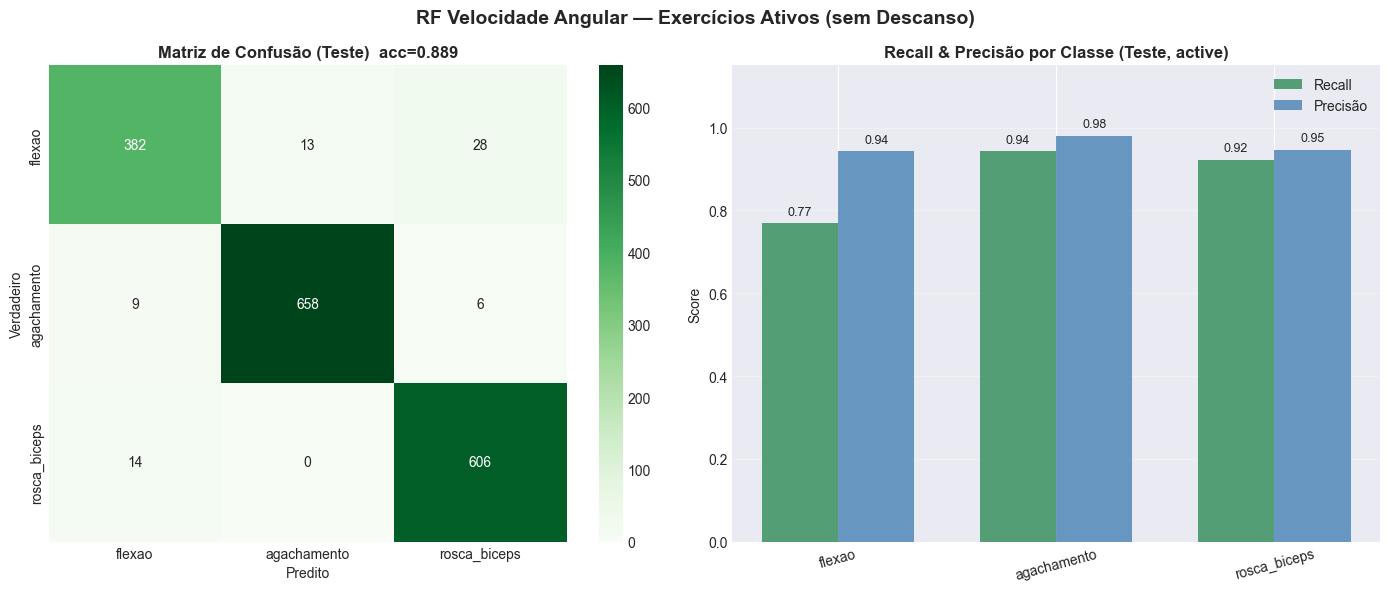

In [16]:
# ── Filtrar apenas exercícios ativos (excluindo descanso) ────────────────────
active_labels = {k: v for k, v in label_map.items() if k != 'descanso'}
active_label_values = list(active_labels.values())

active_mask_test  = y_test.isin(active_label_values)
active_mask_train = y_train.isin(active_label_values)

y_test_active  = y_test[active_mask_test].reset_index(drop=True)
y_train_active = y_train[active_mask_train].reset_index(drop=True)
y_test_pred_act  = y_test_pred[active_mask_test]
y_train_pred_act = y_train_pred[active_mask_train]

active_names = [reverse_label_map[i] for i in sorted(active_label_values)]

acc_train_active = accuracy_score(y_train_active, y_train_pred_act)
acc_test_active  = accuracy_score(y_test_active,  y_test_pred_act)

print("=" * 65)
print("  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)")
print("=" * 65)
print(f"\n  {'Conjunto':<12} {'Acurácia (active)':>18}")
print(f"  {'-'*32}")
print(f"  {'Treino':<12} {acc_train_active:>18.4f}")
print(f"  {'Teste':<12} {acc_test_active:>18.4f}")

print(f"\n{'='*65}")
print("  CLASSIFICATION REPORT — TREINO (active)")
print(f"{'='*65}")
print(classification_report(y_train_active, y_train_pred_act,
                             labels=sorted(active_label_values),
                             target_names=active_names, zero_division=0))

print(f"{'='*65}")
print("  CLASSIFICATION REPORT — TESTE (active)")
print(f"{'='*65}")
print(classification_report(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values),
                             target_names=active_names, zero_division=0))

# ── Gráfico ──────────────────────────────────────────────────────────────────
cm_active = confusion_matrix(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values))
report_active = classification_report(y_test_active, y_test_pred_act,
                                      labels=sorted(active_label_values),
                                      target_names=active_names,
                                      output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RF Velocidade Angular — Exercícios Ativos (sem Descanso)',
             fontsize=14, fontweight='bold')

sns.heatmap(cm_active, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=active_names, yticklabels=active_names)
axes[0].set_title(f'Matriz de Confusão (Teste)  acc={acc_test_active:.3f}',
                  fontweight='bold')
axes[0].set_ylabel('Verdadeiro'); axes[0].set_xlabel('Predito')

rec  = [report_active[c]['recall']    for c in active_names]
prec = [report_active[c]['precision'] for c in active_names]
x = np.arange(len(active_names))
w = 0.35
axes[1].bar(x - w/2, rec,  w, label='Recall',   color='seagreen',  alpha=0.8)
axes[1].bar(x + w/2, prec, w, label='Precisão', color='steelblue', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(active_names, rotation=15)
axes[1].set_ylim([0, 1.15]); axes[1].set_ylabel('Score')
axes[1].set_title('Recall & Precisão por Classe (Teste, active)', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (r, p) in enumerate(zip(rec, prec)):
    axes[1].text(i - w/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Save Model and Artifacts

In [17]:
# print("💾 Salvando artefatos...\n")

# # Salvar pipeline completo (scaler + RF em um único objeto)
# pipe_path = ML_MODELS_DIR / "random_forest_velocity_pipeline.pkl"
# with open(pipe_path, 'wb') as f:
#     pickle.dump(pipe, f)
# pipe_size = pipe_path.stat().st_size / 1024
# print(f"  ✓ Pipeline (scaler + RF): {pipe_path} ({pipe_size:.1f} KB)")

# # Salvar modelo e scaler separadamente
# model_path = ML_MODELS_DIR / "random_forest_velocity_4exercises.pkl"
# with open(model_path, 'wb') as f:
#     pickle.dump(pipe.named_steps['rf'], f)
# model_size = model_path.stat().st_size / 1024
# print(f"  ✓ Modelo RF:              {model_path} ({model_size:.1f} KB)")

# scaler_path = ML_MODELS_DIR / "random_forest_velocity_4exercises_scaler.pkl"
# with open(scaler_path, 'wb') as f:
#     pickle.dump(pipe.named_steps['scaler'], f)
# scaler_size = scaler_path.stat().st_size / 1024
# print(f"  ✓ Scaler:                 {scaler_path} ({scaler_size:.1f} KB)")

# # Salvar label map
# label_map_path = ML_MODELS_DIR / "random_forest_velocity_4exercises_label_map.pkl"
# with open(label_map_path, 'wb') as f:
#     pickle.dump(label_map, f)
# print(f"  ✓ Label Map:              {label_map_path}")

# n_features = pipe.named_steps['scaler'].n_features_in_
# print(f"\n  📐 Scaler treinado com {n_features} features  ({n_features // len(angle_columns)} deltas × {len(angle_columns)} ângulos)")
# print(f"  ℹ️  Inferência: calcule os deltas da janela → scaler.transform → rf.predict")